### 다중분류 이론
- 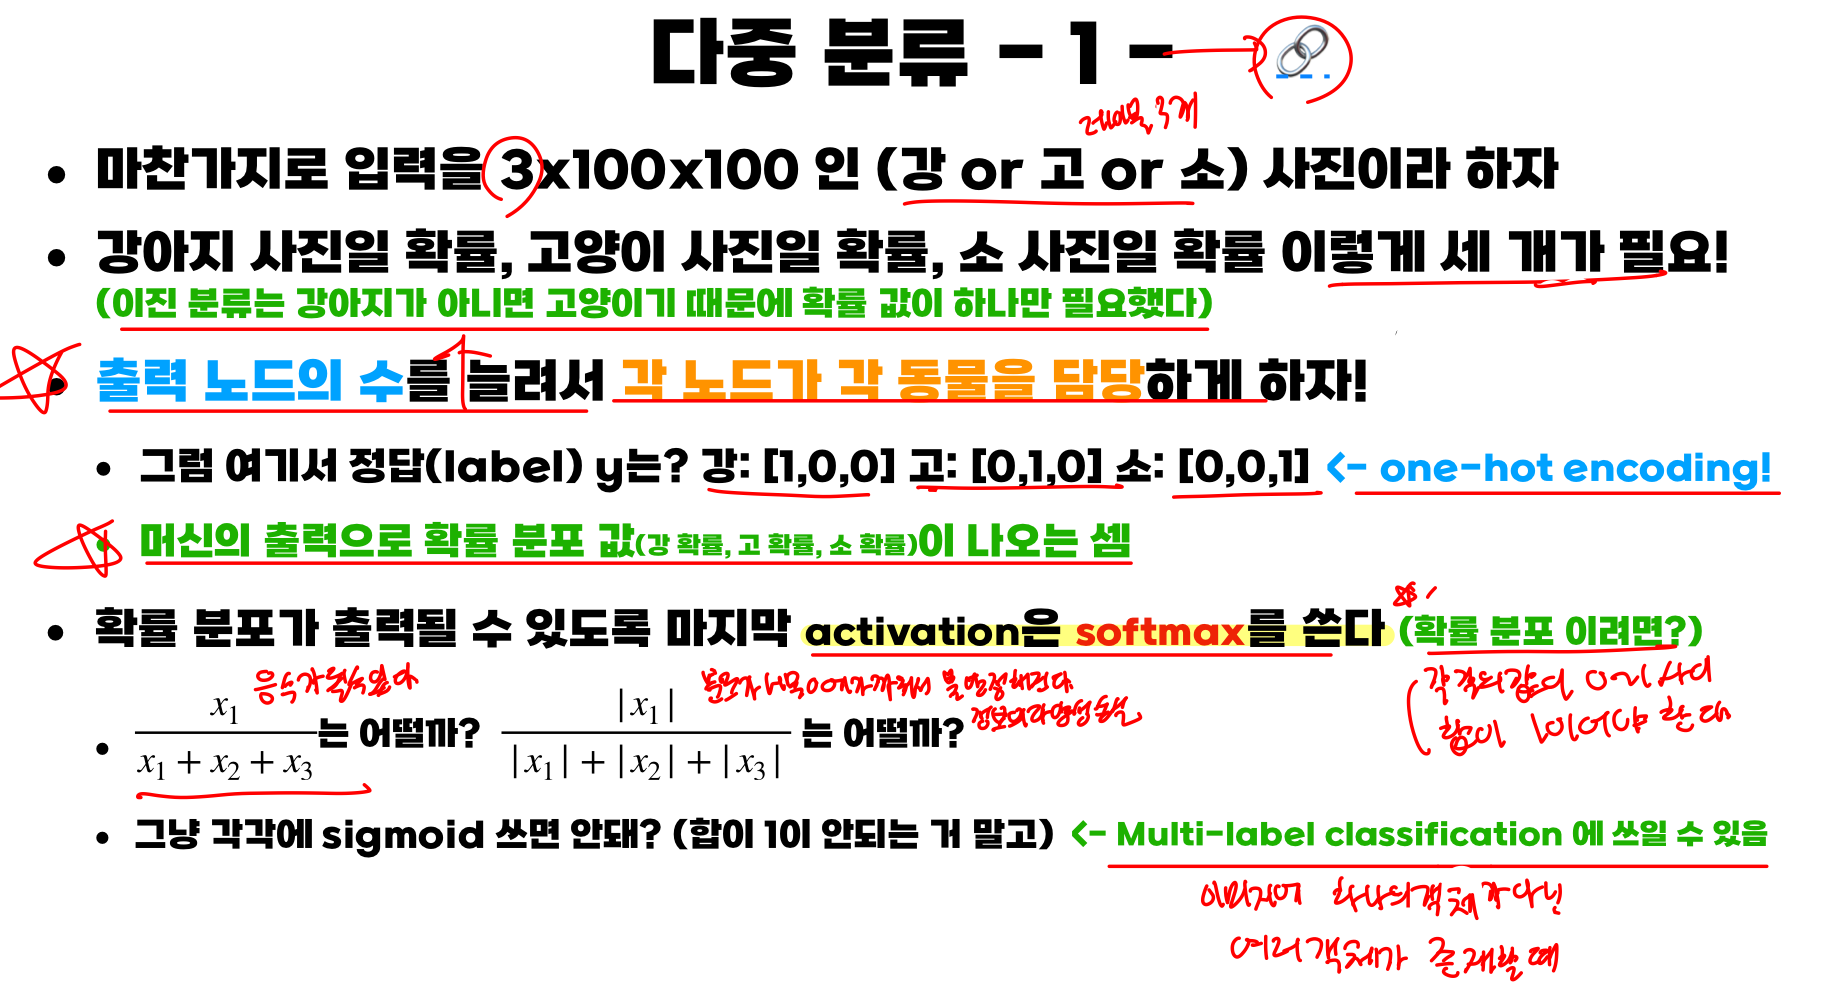
- 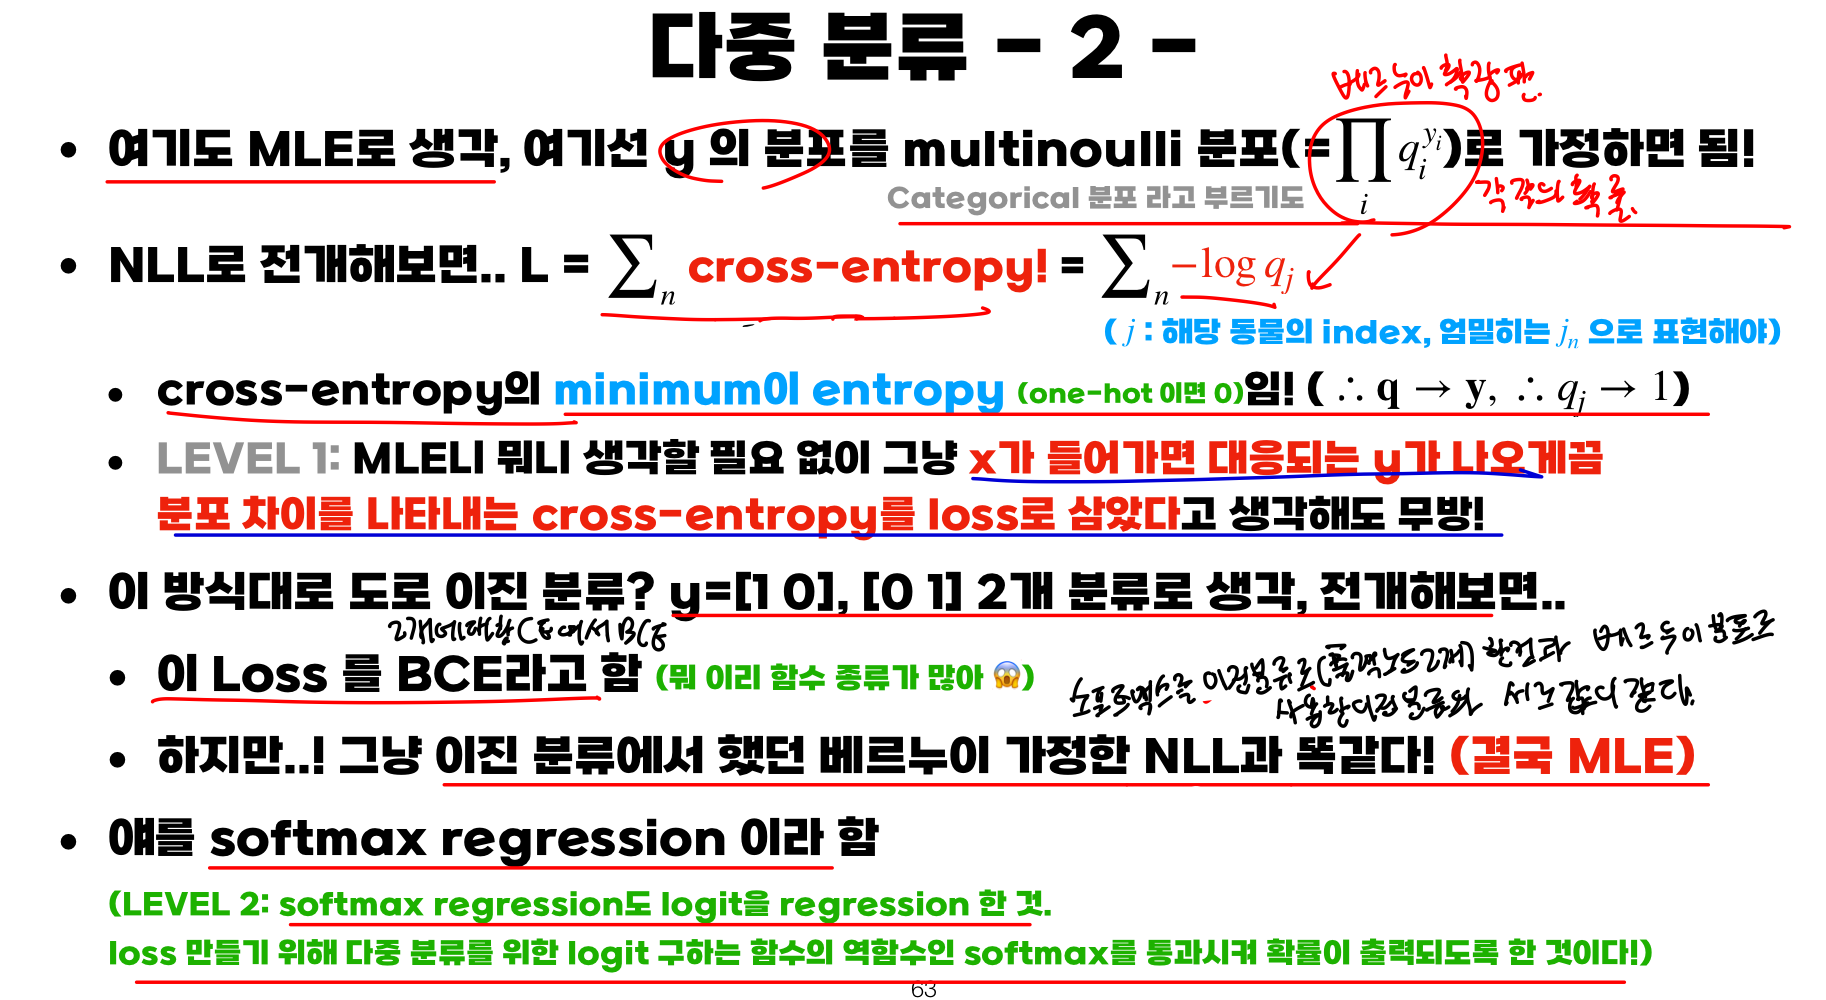
- 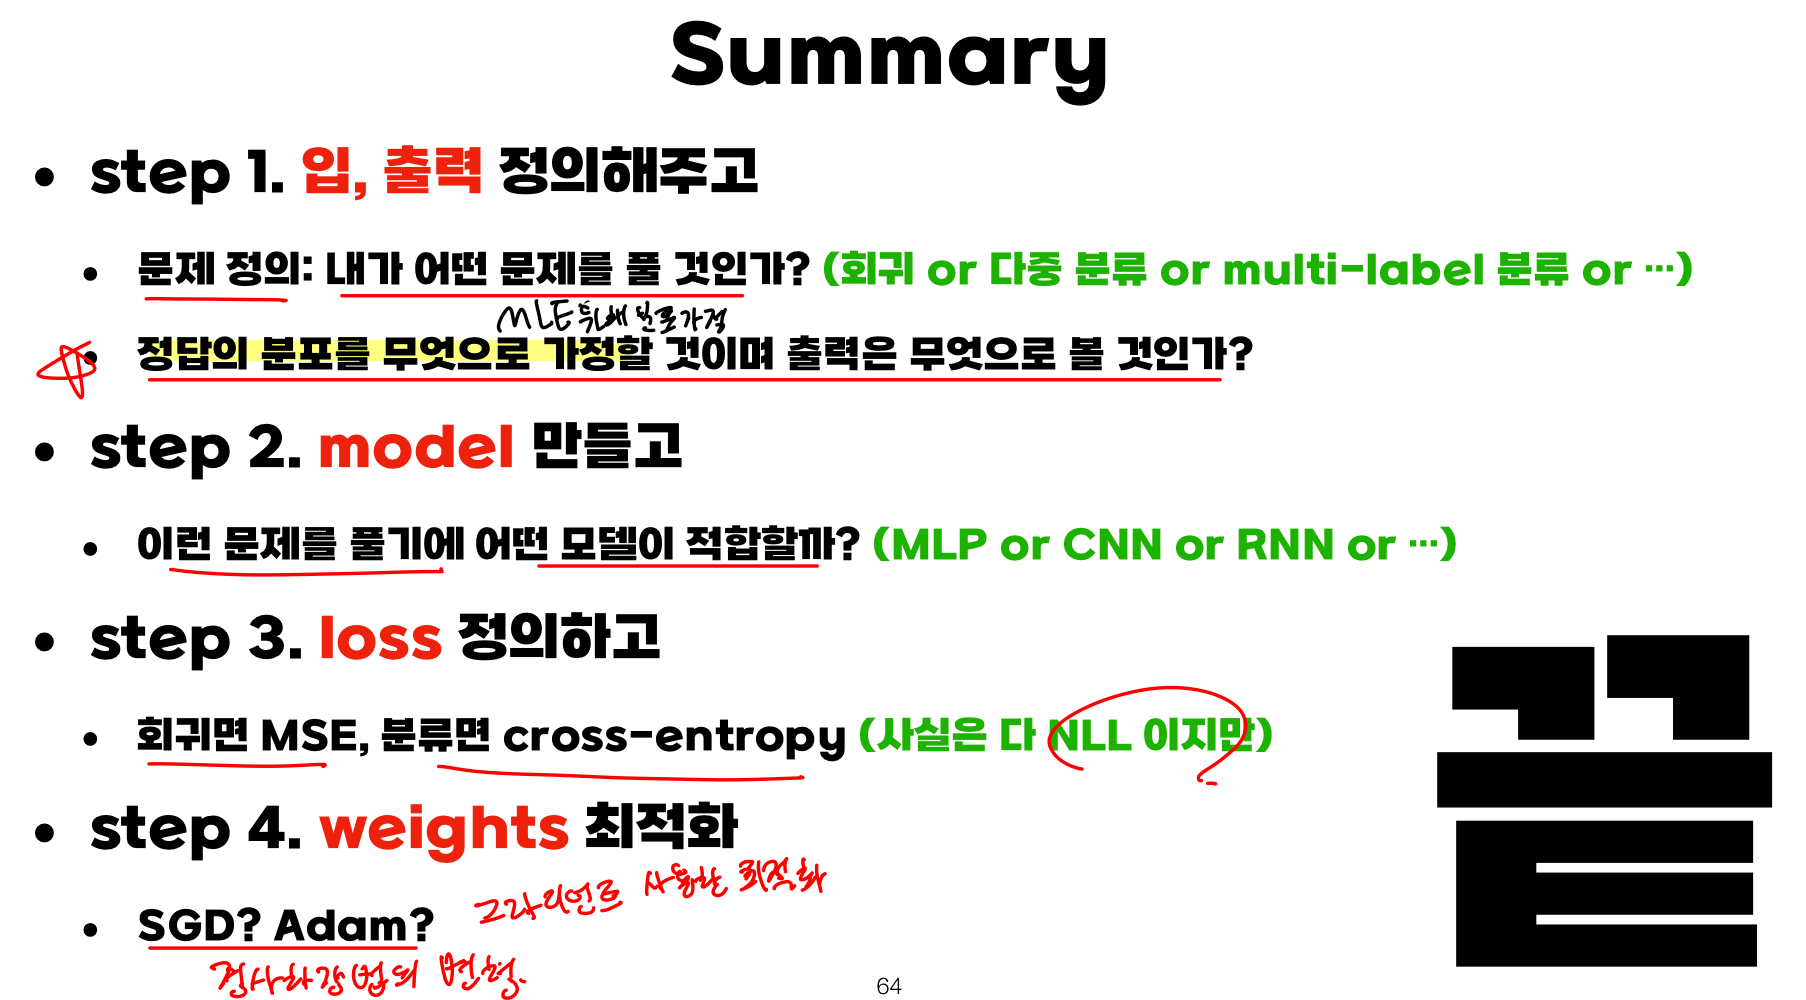

In [1]:
import torch
from torchvision import datasets, transforms #이미지 변형 함수 라이브러리
import matplotlib.pyplot as plt

## 구글 드라이브와 연동 (코랩 새로 켤 때마다 지워지기 땜에)

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 구글 GPU 좀 써보자

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


## train_DS 와 test_DS 구경

In [3]:
transform = transforms.ToTensor()#이미지데터를 텐서형태로 바꿔줌, 모델은 텐서만 입력받음 #/Users/jeonminkyu/Desktop/torch :내경로 ,/content/drive/MyDrive/Colab Notebooks/data: 코랩경로
train_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/torch', train=True, download=True, transform=transform)
test_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/torch', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 345kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.65MB/s]


In [4]:
print(train_DS)
print(test_DS)
print(len(train_DS))
print(len(test_DS))

Dataset MNIST
    Number of datapoints: 60000
    Root location: /content/drive/MyDrive/Colab Notebooks/torch
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Colab Notebooks/torch
    Split: Test
    StandardTransform
Transform: ToTensor()
60000
10000


In [5]:
train_DS.classes # . 뒤에서 탭 하면 이것저것 볼 수 있는 게 뜬다, 다양한 속성이나 메서드존재

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [6]:
train_DS.class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [7]:
train_DS.data.shape

torch.Size([60000, 28, 28])

In [8]:
train_DS.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

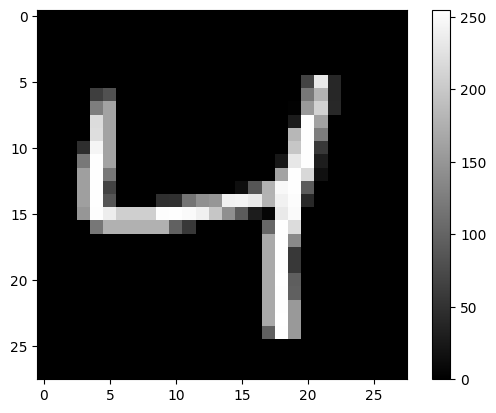

In [9]:
plt.imshow(train_DS.data[2], cmap="gray")
plt.colorbar()

In [10]:
print(train_DS.targets) #정답레이블이 저장되어있다.
print(train_DS.targets.shape)
# print(test_DS.targets)
print(test_DS.targets.shape)

tensor([5, 0, 4,  ..., 5, 6, 8])
torch.Size([60000])
torch.Size([10000])


## DataLoader 구경

In [11]:
#torch.utils.data.DataLoader는 데이터셋에서 원하는 값만큼 추출해준다.
#미니배치사이즈32로 정하고 추출시 섞어서 추출되게 설정
BATCH_SIZE = 32
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [12]:
train_DL.dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: /content/drive/MyDrive/Colab Notebooks/torch
    Split: Train
    StandardTransform
Transform: ToTensor()

### dataloader로 데이터 추출할떄 transform 모듈을 거쳐서 꺼낸다.
- 위에서 transform의 정의를 ToTensor를 사용해서 정의함(transform =transform.ToTensor() ), 따라서 데이터 추출시 정의한 transform모듈을 거쳐서 추출된다.
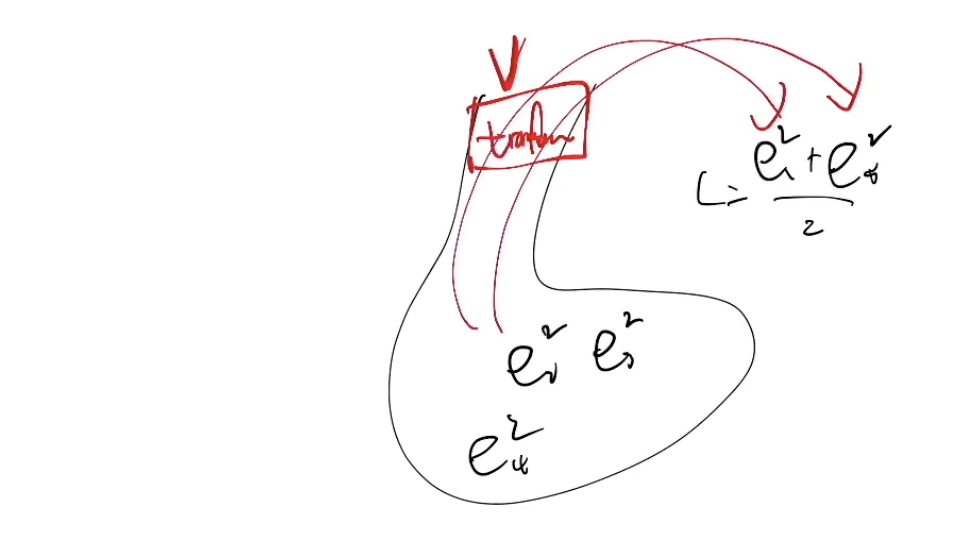

#### ToTensor 의 역할
1. tensor 로 바꾸고
    - numpy배열을 torch.tensor형태의 텐서로 바꿈
2. 개채행열로 바꾸고 (torch는 이미지데이터에대해 4d형태의 데이터 텐서타입을 요구함,따라서 이미지데이터는 개,채,행,열인 형태로 만들어 줘야한다.)
    - mnist데이터 기준예시로 학습:(60000,1(흑백채널),28,28(이미지 크기)),
    - mnist데이터 기준예시로 테스트:(10000,1(흑백채널),28,28(이미지 크기))
3. 0~1 사이로 바꾸고 (int -> float) 
    - 0~255스케일을 0~1스케일로 바꿈 , 어차피 weight초기값은 0~1사이 값이기떄문에 굳이 큰 스케일 사용필요 x
    - 미분가능한 연속데이터로 바꿈(모델이 데이터 학습 가증하게 ) ,  정수형->실수형


<class 'torch.Tensor'>
torch.Size([60000, 28, 28])
torch.uint8
tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,

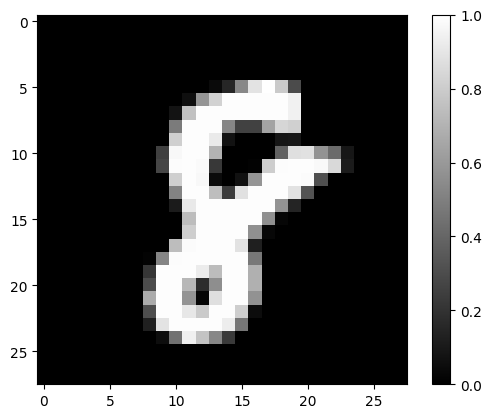

In [13]:
x_batch, y_batch = next(iter(train_DL)) # 데이터 한 국자 # next(iter(train_DS)) 는 한장만 꺼내기, 데이터32개(한 batch) 와 데이터레이블 가져옴
# ToTensor 의 역할
# 1. tensor 로 바꾸고
# 2. 개채행열로 바꾸고
# 3. 0~1 사이로 바꾸고 (int -> float)
print(type(train_DS.data))
print(train_DS.data.shape)
print(train_DS.data.dtype)
print(train_DS.data[0])

print(type(x_batch))
print(x_batch.shape) # ->개채행열 형태로 잘 변환됨
print(x_batch.dtype)
print(x_batch[0])

plt.imshow(x_batch[0].permute(1,2,0),cmap='gray')
plt.colorbar()
print(y_batch[0])

## 본격적으로 model 만들기!

In [14]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fcs = nn.Sequential(nn.Linear(28*28, 100),
                                 nn.ReLU(),
                                 nn.Linear(100, 10))
    def forward(self, x):
        x = torch.flatten(x, start_dim=1) #첫번쨰 차원뺴고 나머지를 flatten해라
        x = self.fcs(x)
        return x

### flatten하는 이유: nn.linear의 기대값은 개,채의 형태이다. 즉 4차원인 개채행렬이아니라 2차원인 개,채형태로 입력받음 여기서 채널은 feature값을 의미 
- 데이터가 4차원(개채행렬)형태인걸 linear노드에 각각 넣어야하니 픽셀형태를 일자로 펼쳐서 각 linear노드에 입력되게 함 여기서 batchsize 32는 그대로 나머지 이미지 구성하는 요소인 채널,행,열은 각 픽셀 하나하나로 펼쳐서 만듬
- nn.Linear(28*28, 100) = 784입력->100출력 따라서 입력을 784차원으로 만들어야함

In [15]:
# flatten 확인
x_batch, _ = next(iter(train_DL))
print(x_batch.shape)
flat_images = torch.flatten(x_batch)
print(flat_images.shape) #x_batch.shape(32,1,28,28)을 1차원으로 flatten:32x1x28x28 = 25088
flat_images2 = torch.flatten(x_batch, start_dim=1)
print(flat_images2.shape)

torch.Size([32, 1, 28, 28])
torch.Size([25088])
torch.Size([32, 784])


### 모델 통과후 batch size 32개에 대한 10개의 logit(확률분포함수 통과전 모델의 출력값)생성 완료

In [16]:
model=MLP().to(DEVICE) #모델이 gpu로 올라가있음->gpu로 계산 가능
print(model)

x_batch, _ = next(iter(train_DL))
print(x_batch.shape)

model.eval()
with torch.no_grad():
    print(model(x_batch.to(DEVICE)).shape) #to.('cuda')->gpu사용, cpu에있는걸 gpu로 옮겨서 계산

MLP(
  (fcs): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)
torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


## 모델 훈련시키기!

### loss구할떄 batch size가 안맞는데 전체loss를 합한후 /2하면 한 epoch당 잘못된 loss가 구해진다 따라서 각 loss를 batchsize로 나누어 구한후 합하고 마지막에 전체 데이터 개수에 대한 값으로 나누어 한 epoch당 정확한 loss를 구한다.
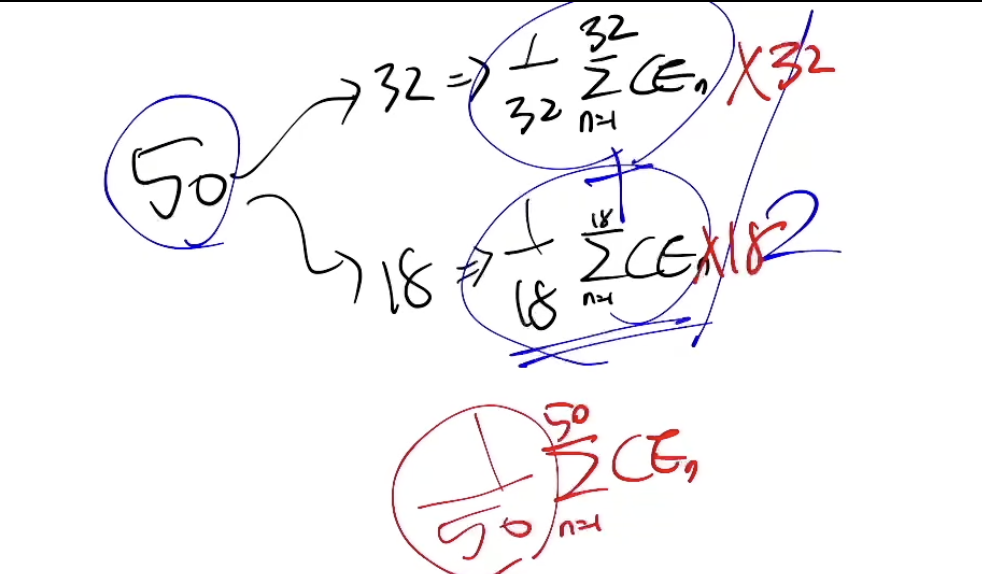

In [17]:
from torch import optim

LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

def Train(model, train_DL, criterion, optimizer, EPOCH):

    loss_history=[]
    NoT=len(train_DL.dataset) # The number of training data

    model.train() # train mode로 전환
    for ep in range(EPOCH):
        rloss = 0 # running loss
        for x_batch, y_batch in train_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # inference
            y_hat = model(x_batch)
            # loss
            loss = criterion(y_hat, y_batch)
            # update
            optimizer.zero_grad() # gradient 누적을 막기 위한 초기화
            loss.backward() # backpropagation
            optimizer.step() # weight update
            # loss accumulation
            loss_b = loss.item() * x_batch.shape[0] # batch loss # BATCH_SIZE를 곱하면 마지막 18개도 32개를 곱하니까.. 마지막 batch size안맞는거 고려해서 한 epoch당 평균 loss구함
            rloss += loss_b # running loss
        # print loss
        loss_e = rloss/NoT # epoch loss ->한 epoch당 정확한 loss 구하기
        loss_history += [loss_e]
        print(f"Epoch: {ep+1}, train loss: {loss_e:.3f}")
        print("-"*20)

    return loss_history

## Cross Entropy 확인 (왜 모델에 softmax를 안붙였을까?)
- torch에서 구현할떄 Cross Entropy Loss에 softmax를 포함해서 구현해놓음
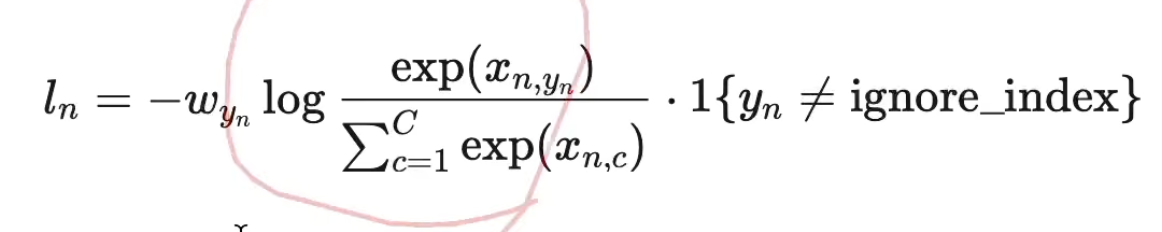


In [18]:
# cross entropy 구하는 여러가지 방법
import torch.nn.functional as F

y_hat = torch.randn(3, 5) # data는 세 개, 5 종류로 분류하는 문제 가정
print(y_hat) # 가로 축으로 합이 1이 아님, 즉, softmax 통과 전
y_batch = torch.randint(5, (3,))
print(y_batch)

# 방법 1
loss = F.cross_entropy(y_hat, y_batch) # softmax가 내장
print('방법1',loss)

# 방법 2
criterion = nn.CrossEntropyLoss() # softmax가 내장
print('방법2',criterion(y_hat,y_batch))

# 방법 3
soft = nn.Softmax(dim=1)
y_hat_soft = soft(y_hat)
print(y_hat_soft)
loss = 0
for i, val in enumerate(y_hat_soft):
    print(i,val)
    loss += -torch.log(val[y_batch[i]])
print('방법3',loss/3) # 평균이 내장되어있음을 알 수 있다

tensor([[ 0.7071, -0.3679, -0.3712, -0.8927, -0.0167],
        [-1.3385,  0.5710, -0.7609, -0.8027, -0.1706],
        [ 0.9979,  0.9001,  0.9169, -0.5798,  1.3978]])
tensor([0, 2, 4])
방법1 tensor(1.3553)
방법2 tensor(1.3553)
tensor([[0.4222, 0.1441, 0.1436, 0.0853, 0.2048],
        [0.0692, 0.4669, 0.1233, 0.1182, 0.2224],
        [0.2209, 0.2003, 0.2037, 0.0456, 0.3295]])
0 tensor([0.4222, 0.1441, 0.1436, 0.0853, 0.2048])
1 tensor([0.0692, 0.4669, 0.1233, 0.1182, 0.2224])
2 tensor([0.2209, 0.2003, 0.2037, 0.0456, 0.3295])
방법3 tensor(1.3553)


Epoch: 1, train loss: 0.314
--------------------
Epoch: 2, train loss: 0.142
--------------------
Epoch: 3, train loss: 0.099
--------------------
Epoch: 4, train loss: 0.074
--------------------
Epoch: 5, train loss: 0.060
--------------------


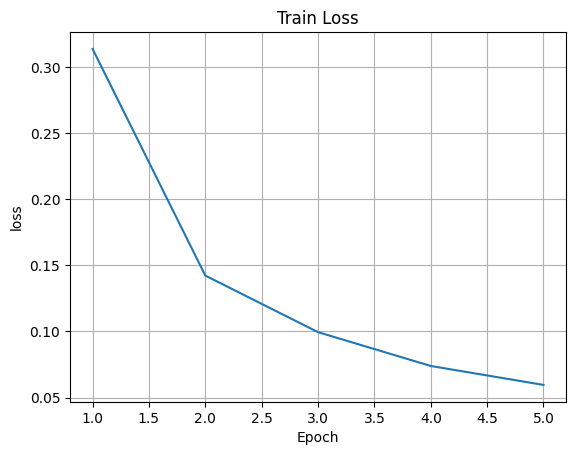

In [19]:
loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

plt.plot(range(1,EPOCH+1),loss_history)
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Train Loss")
plt.grid()

## 모델 저장하기 & 불러오기
- state_dict()를 통해 모델이 가지는 파라미터를 dict형태로 저장, 확장자.pt파일로

In [20]:
#모델 파라미터 weight,bias확인하기
model.state_dict()

OrderedDict([('fcs.0.weight',
              tensor([[ 0.0243,  0.0101, -0.0138,  ..., -0.0120,  0.0067,  0.0288],
                      [-0.0025,  0.0303,  0.0260,  ..., -0.0153,  0.0020,  0.0180],
                      [ 0.0031, -0.0212,  0.0319,  ...,  0.0048, -0.0278, -0.0260],
                      ...,
                      [-0.0127,  0.0103,  0.0050,  ...,  0.0002,  0.0103, -0.0240],
                      [ 0.0163, -0.0237,  0.0220,  ...,  0.0068,  0.0332,  0.0328],
                      [-0.0161, -0.0184,  0.0218,  ..., -0.0202, -0.0243, -0.0238]],
                     device='cuda:0')),
             ('fcs.0.bias',
              tensor([ 0.0806,  0.0325, -0.0630,  0.0818, -0.0809, -0.1119,  0.0114,  0.0068,
                       0.0260,  0.1264,  0.0833,  0.1546, -0.0169,  0.1384,  0.0812,  0.0923,
                      -0.0075,  0.1746, -0.1878,  0.0980,  0.1418, -0.1704,  0.1251, -0.0853,
                      -0.0607,  0.0907,  0.0571, -0.0104,  0.0449, -0.0453, -0.0201,  0.

In [ ]:
#마운트 확인 코드
import os
print(os.getcwd())
print(os.path.isdir("/content/drive"))
print(os.listdir("/content/drive")[:5])


/content
True
['MyDrive']


In [28]:
import os

path = "/content/drive/MyDrive/Colab Notebooks/torch/results"
print(os.path.isdir(path))
print(os.listdir(path))


True
['MLP.pt']


In [27]:
# import os # 이건 내 필기용
# os.mkdir("/content/drive/MyDrive/Colab Notebooks/results") # 이건 내 필기용
#colab용
# save_model_path = "/content/drive/MyDrive/Colab Notebooks/results/MLP.pt"
# torch.save(model.state_dict(), save_model_path)

#vscode로컬용
import os
#os.mkdir('/Users/jeonminkyu/Desktop/torch/results')
os.makedirs("/content/drive/MyDrive/Colab Notebooks/torch/results", exist_ok=True)
save_model_path = "/content/drive/MyDrive/Colab Notebooks/torch/results/MLP.pt"
torch.save(model.state_dict(), save_model_path) #모델의 정보(파라미터값)를 해당 경로에 저장

In [22]:
load_model = MLP().to(DEVICE) #학습안된 껍데기 모델 만들기
load_model.load_state_dict(torch.load(save_model_path, map_location=DEVICE)) #저장된 모델 파라미터 불러오기,map_location=DEVICE으로 DEVICE장치로 로드해라 
# map_location 있어야 GPU로 학습했던 거 현재 device로 불러올 수 있음

<All keys matched successfully>

## 모델 테스트하기

### test시에 model.eval()-> dropout이나 batchnormalization처럼 학습떄와 테스트시 동작이 다르기 떄문에 구분 과 torch.no_grad() ->테스트시에는 미분할거아니니까 graident 추적 x 는 항상 사용

In [23]:
def Test(model, test_DL):
    model.eval() # test mode로 전환
    with torch.no_grad():
        rcorrect = 0 #rloss처럼 정답값 누적하기위해, torch에는 acc구현x
        for x_batch, y_batch in test_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            # inference
            y_hat = model(x_batch)
            # print(y_hat)
            # break

            # corrects accumulation
            pred = y_hat.argmax(dim=1)
            corrects_b = torch.sum(pred == y_batch).item() # torch.eq(pred, y_batch).sum().item()
            rcorrect += corrects_b
            # print(pred) ->직접 확인 ,예측과 정답레이블
            # print(y_batch)
            # break

        accuracy_e = rcorrect/len(test_DL.dataset)*100 #->정확도 accuracy지표 만듬
    print(f"Test accuracy: {rcorrect}/{len(test_DL.dataset)} ({accuracy_e:.1f} %)")
    return round(accuracy_e,1)

In [24]:
Test(load_model, test_DL)

Test accuracy: 9711/10000 (97.1 %)


97.1

In [25]:
def Test_plot(model, test_DL):
    model.eval()
    with torch.no_grad():
        x_batch, y_batch = next(iter(test_DL))
        x_batch = x_batch.to(DEVICE)
        y_hat = model(x_batch)
        pred = y_hat.argmax(dim=1)

    x_batch = x_batch.to("cpu")
    # print(x_batch.shape)

    plt.figure(figsize=(8,4))
    for idx in range(6):
        plt.subplot(2,3, idx+1, xticks=[], yticks=[])
        plt.imshow(x_batch[idx].permute(1,2,0), cmap="gray")
        pred_class = test_DL.dataset.classes[pred[idx]]
        true_class = test_DL.dataset.classes[y_batch[idx]]
        plt.title(f"{pred_class} ({true_class})", color = "g" if pred_class==true_class else "r") #정답과 예측이 맞으면 초록 아니면 빨강으로 표시

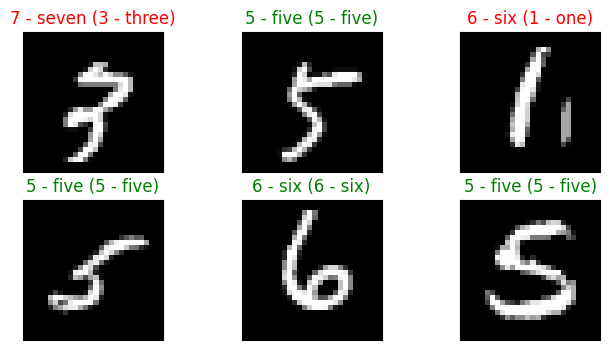

In [40]:
Test_plot(load_model, test_DL)

In [41]:
# 파라미터 수 구하기
def count_params(model):
    num = sum([p.numel() for p in model.parameters() if p.requires_grad])
    return num

### Mlp모델을 가지고 분류했기떄문에 파라미터 수가 많다. (cnn구조 같이 사용하면 적은 파라미터수로 더 좋은 성능 가능하다.)

In [42]:
print(count_params(load_model))

79510


## confusion matrix

In [43]:
def get_conf(model, test_DL):
    N = len(test_DL.dataset.classes)
    model.eval()
    with torch.no_grad():
        confusion = torch.zeros(N,N)
        for x_batch, y_batch in test_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # inference
            y_hat = model(x_batch)
            # accuracy
            pred = y_hat.argmax(dim=1)

            confusion += torch.bincount(N * y_batch.cpu() + pred.cpu(), minlength=N**2).reshape(N, N)
            # confusion matrix는 무조건 10x10이 되어야 하는데 만약 마지막 label에 대해 예측을 모두 실패하면 100개보다 작아질 수 있기 때문에 minlength를 설정

    confusion = confusion.numpy()

    return confusion

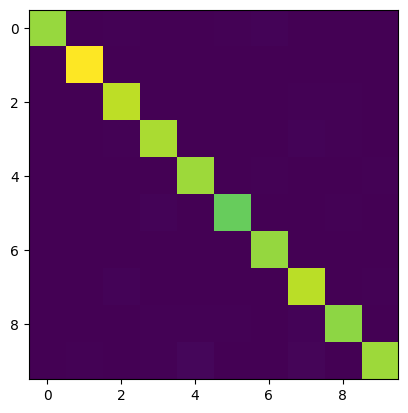

In [44]:
confusion = get_conf(load_model, test_DL)
plt.imshow(confusion)

In [45]:
import numpy as np

def plot_confusion_matrix(confusion, classes=None):
    N = confusion.shape[0]
    accuracy=np.trace(confusion)/np.sum(confusion) * 100

    # confusion = confusion/np.sum(confusion, axis=1)
    plt.figure(figsize=(10,7))
    plt.imshow(confusion, cmap="Blues")
    plt.title("confusion matrix")
    plt.colorbar()

    for i in range(N):
        for j in range(N):
            plt.text(j,i, round(confusion[i,j]),
                     horizontalalignment="center", fontsize=10,
                     color="white" if confusion[i,j] > np.max(confusion) / 1.5 else "black")

    if classes is not None:
        plt.xticks(range(N), classes)
        plt.yticks(range(N), classes)
    else:
        plt.xticks(range(N))
        plt.yticks(range(N))

    plt.xlabel(f"Predicted label \n accuracy = {accuracy:.1f} %")
    plt.ylabel("True label")

### 모델이 레이블중에 어떤것을 얼마나 맞추고 얼마나 틀린지 알수있다. (혼동행렬의 값을 다더하면 10000(test개수)이 나온다)
### confusion matrix로 어떤레이블을 모델이 어느레이블로 잘못 분류했는지 한눈에 보기 좋다.
### 가장많이 못맞춘 5레이블에서 모델이 3으로 많이 오분류했구나, 모델성능을 높일떄 활용 좋음

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '0 - zero'),
  Text(1, 0, '1 - one'),
  Text(2, 0, '2 - two'),
  Text(3, 0, '3 - three'),
  Text(4, 0, '4 - four'),
  Text(5, 0, '5 - five'),
  Text(6, 0, '6 - six'),
  Text(7, 0, '7 - seven'),
  Text(8, 0, '8 - eight'),
  Text(9, 0, '9 - nine')])

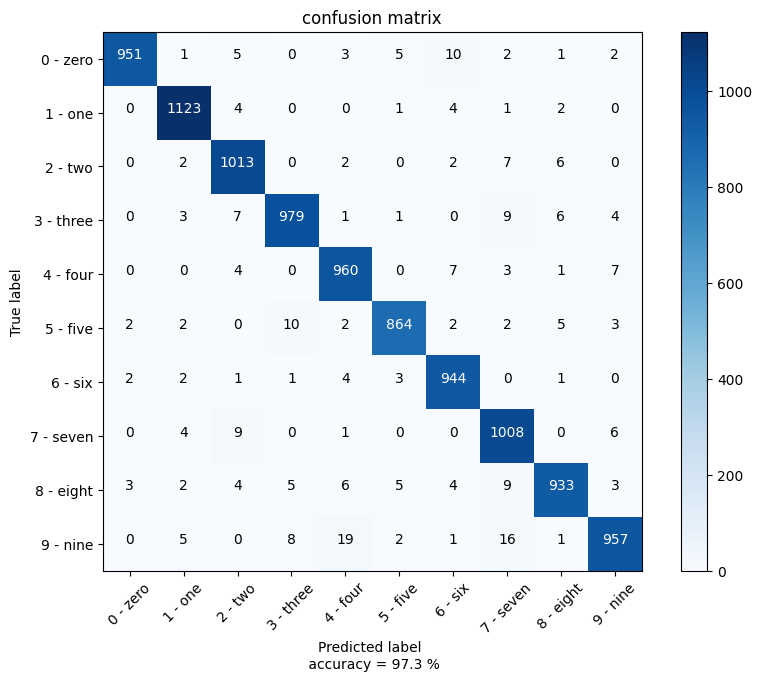

In [ ]:
#모델이 레이블중에 어떤것을 얼마나 맞추고 얼마나 틀린지 알수있다. (혼동행렬의 값을 다더하면 10000(test개수)이 나온다)
# confusion matrix로 어떤레이블을 모델이 어느레이블로 잘못 분류했는지 한눈에 보기 좋다.
# 가장많이 못맞춘 5레이블에서 모델이 3으로 많이 오분류했구나, 모델성능을 높일떄 활용 좋음
confusion = get_conf(load_model, test_DL)
plot_confusion_matrix(confusion, test_DS.classes)
plt.xticks(rotation=45)
#plt.xticks(rotation=45); ->jupyter,colab에서 ;를붙이면 셀출력 지움